# House Prices — Model Comparison

**Goal.** The exploratory analysis and preprocessing live in `EDA.ipynb`, which writes a clean,
fully-numeric, feature-selected dataset to `data/processed/`. This notebook picks up from there: it
trains **seven regression models**, evaluates each with the same cross-validation scheme, compares
them, and uses the best one to generate the Kaggle submission.

The Kaggle competition is scored with **RMSLE** (Root Mean Squared *Log* Error). To match that, we
train every model on `log1p(SalePrice)` and report the cross-validated **RMSE on the log target**
(which equals the competition's RMSLE) together with the **R²**.

RMSLE ≈ "average percentage error,"

## 1. Setup & data

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [9]:
# Robust path: works whether the notebook runs from notebooks/ or the repo root
for cand in [Path("../data/processed"), Path("data/processed"), Path("../../data/processed")]:
    if cand.exists():
        DATA = cand
        break
REPO_ROOT = DATA.resolve().parent.parent

X       = pd.read_csv(DATA / "X_train.csv")
y_raw   = pd.read_csv(DATA / "y_train.csv")["SalePrice"]
test    = pd.read_csv(DATA / "test.csv")
test_id = pd.read_csv(DATA / "ID's.csv")["Id"]

print("Train features:", X.shape, " Test features:", test.shape)
print("Columns:", list(X.columns))
X.head()

Train features: (1460, 13)  Test features: (1459, 13)
Columns: ['OverallQual', '2ndFlrSF', '1stFlrSF', 'GarageArea', 'BsmtFinSF1', 'LotArea', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF', 'YearRemodAdd', 'BsmtUnfSF', 'YearBuilt', 'GarageYrBlt']


,OverallQual,2ndFlrSF,1stFlrSF,GarageArea,BsmtFinSF1,LotArea,MasVnrArea,OpenPorchSF,WoodDeckSF,YearRemodAdd,BsmtUnfSF,YearBuilt,GarageYrBlt
0,7,854,856,548,706,8450,196.0,61,0,2003,150,2003,2003.0
1,6,0,1262,460,978,9600,0.0,0,298,1976,284,1976,1976.0
2,7,866,920,608,486,11250,162.0,42,0,2002,434,2001,2001.0
3,7,756,961,642,216,9550,0.0,35,0,1970,540,1915,1998.0
4,8,1053,1145,836,655,14260,350.0,84,192,2000,490,2000,2000.0


## 2. Target transform

`SalePrice` is strongly right-skewed (a few very expensive houses stretch the tail). Because Kaggle
scores on the log of the price, we model **`log1p(SalePrice)`**. This makes the error symmetric in
percentage terms and lines our validation metric up with the leaderboard metric. Predictions are
converted back with `expm1` before submission.

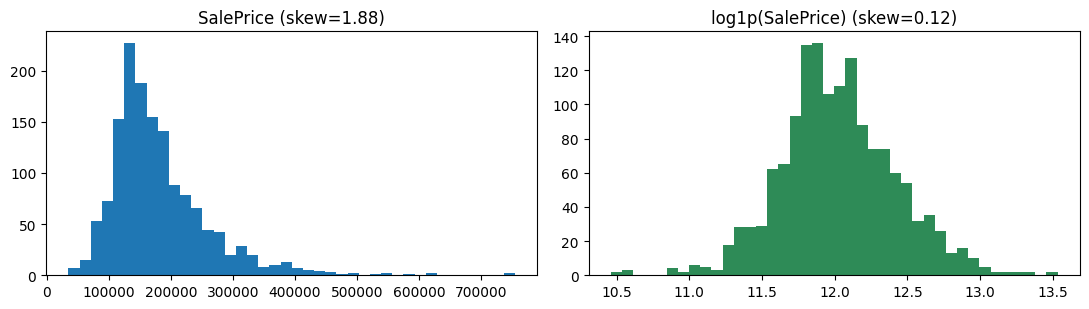

In [10]:
y = np.log1p(y_raw)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(y_raw, bins=40); ax[0].set_title(f"SalePrice (skew={y_raw.skew():.2f})")
ax[1].hist(y, bins=40, color="seagreen"); ax[1].set_title(f"log1p(SalePrice) (skew={y.skew():.2f})")
plt.tight_layout(); plt.show()

## 3. Evaluation protocol

Every model is scored with the **same** 5-fold `KFold` split (shuffled, fixed seed) so the comparison
is fair. `evaluate()` returns the mean ± std of the per-fold **RMSLE** and the mean **R²**. Scale-
sensitive linear models are wrapped in a `StandardScaler` pipeline; tree/boosting models are scale-
invariant and used directly.

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results, estimators = {}, {}

def evaluate(name, model):
    cv = cross_validate(model, X, y, cv=kf, n_jobs=-1,
                        scoring={"mse": "neg_mean_squared_error", "r2": "r2"})
    rmse = np.sqrt(-cv["test_mse"])
    results[name] = {"CV_RMSLE": rmse.mean(), "RMSLE_std": rmse.std(), "CV_R2": cv["test_r2"].mean()}
    estimators[name] = model
    print(f"{name:18s} RMSLE = {rmse.mean():.5f} (+/- {rmse.std():.5f})   R2 = {cv['test_r2'].mean():.4f}")
    return results[name]

## 4. The models

### 4.1 Linear Regression
The plain ordinary-least-squares baseline. Fast and interpretable, but it can only fit a straight,
additive relationship between the features and the (log) price.

In [12]:
evaluate("LinearRegression", make_pipeline(StandardScaler(), LinearRegression()));

LinearRegression   RMSLE = 0.17003 (+/- 0.04270)   R2 = 0.8000


### 4.2 Ridge
Linear regression with **L2** regularization (penalizes large coefficients). The strength `alpha` is
chosen automatically by `RidgeCV`. It curbs overfitting but, being linear, shares OLS's ceiling.

In [13]:
evaluate("Ridge", make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 50))));

Ridge              RMSLE = 0.17109 (+/- 0.04187)   R2 = 0.7984


### 4.3 Lasso
Linear regression with **L1** regularization, which can drive weak coefficients to exactly zero
(automatic feature selection). `LassoCV` tunes `alpha`.

In [14]:
evaluate("Lasso", make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 1, 50), max_iter=50000)));

Lasso              RMSLE = 0.16798 (+/- 0.03657)   R2 = 0.8087


### 4.4 Random Forest
An ensemble of decorrelated decision trees averaged together. It captures non-linearities and feature
interactions with no manual effort and is robust to outliers.

In [15]:
evaluate("RandomForest", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1));

RandomForest       RMSLE = 0.15784 (+/- 0.02104)   R2 = 0.8383


### 4.5 Gradient Boosting
Trees built **sequentially**, each correcting the previous one's residuals. Usually stronger than a
random forest on tabular data, at the cost of more careful tuning.

In [16]:
evaluate("GradientBoosting", GradientBoostingRegressor(random_state=42));

GradientBoosting   RMSLE = 0.15252 (+/- 0.01819)   R2 = 0.8495


### 4.6 XGBoost
A fast, regularized gradient-boosting implementation. We do a small grid search over learning rate,
tree depth, number of trees and L2 strength (scored on RMSLE), then evaluate the tuned model.

In [17]:
xgb_grid = {"n_estimators": [300, 600], "learning_rate": [0.03, 0.05],
            "max_depth": [3, 4], "reg_lambda": [1.0, 5.0]}
xgb_base = XGBRegressor(objective="reg:squarederror", subsample=0.8, colsample_bytree=0.8,
                        random_state=42, n_jobs=-1, verbosity=0)
gs_xgb = GridSearchCV(xgb_base, xgb_grid, scoring="neg_mean_squared_error", cv=kf, n_jobs=-1).fit(X, y)
print("Best XGB params:", gs_xgb.best_params_)
evaluate("XGBoost", XGBRegressor(objective="reg:squarederror", subsample=0.8, colsample_bytree=0.8,
                                 random_state=42, n_jobs=-1, verbosity=0, **gs_xgb.best_params_));

Best XGB params: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300, 'reg_lambda': 5.0}
XGBoost            RMSLE = 0.14607 (+/- 0.01663)   R2 = 0.8627


### 4.7 LightGBM
A leaf-wise gradient-boosting library, typically very fast. Same small grid-search-then-evaluate
recipe as XGBoost.

In [18]:
lgb_grid = {"n_estimators": [300, 600], "learning_rate": [0.03, 0.05],
            "num_leaves": [15, 31], "reg_lambda": [1.0, 5.0]}
lgb_base = LGBMRegressor(subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
gs_lgb = GridSearchCV(lgb_base, lgb_grid, scoring="neg_mean_squared_error", cv=kf, n_jobs=-1).fit(X, y)
print("Best LGB params:", gs_lgb.best_params_)
evaluate("LightGBM", LGBMRegressor(subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   n_jobs=-1, verbose=-1, **gs_lgb.best_params_));

Best LGB params: {'learning_rate': 0.03, 'n_estimators': 300, 'num_leaves': 15, 'reg_lambda': 5.0}
LightGBM           RMSLE = 0.14798 (+/- 0.01736)   R2 = 0.8588


## 5. Comparison

(RMSLE_std-->how much the score bounced around from fold to fold)

,model,CV_RMSLE,RMSLE_std,CV_R2
0,XGBoost,0.146073,0.016634,0.862717
1,LightGBM,0.147978,0.017363,0.858783
2,GradientBoosting,0.152521,0.018193,0.849520
3,RandomForest,0.157841,0.021043,0.838277
4,Lasso,0.167983,0.036567,0.808657
5,LinearRegression,0.170032,0.042697,0.799989
6,Ridge,0.171092,0.041869,0.798421


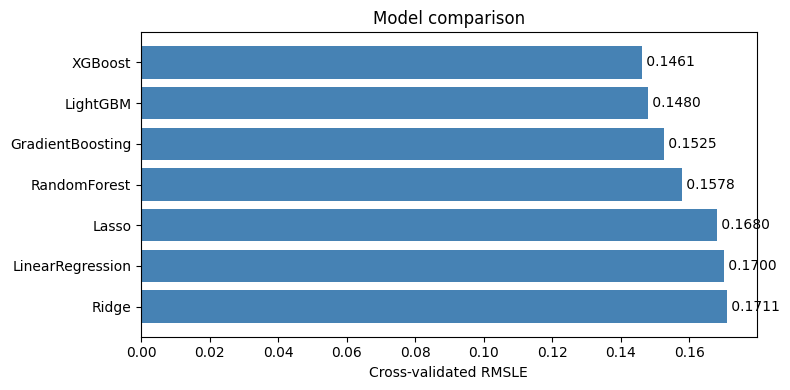

In [20]:
res = (pd.DataFrame(results).T
         .sort_values("CV_RMSLE")
         .reset_index().rename(columns={"index": "model"}))
display(res)

plt.figure(figsize=(8, 4))
plt.barh(res["model"][::-1], res["CV_RMSLE"][::-1], color="steelblue")
plt.xlabel("Cross-validated RMSLE")
plt.title("Model comparison")
for i, v in enumerate(res["CV_RMSLE"][::-1]):
    plt.text(v, i, f" {v:.4f}", va="center")
plt.tight_layout(); plt.show()

## 6. Conclusion — which model is best, and why

**Gradient-boosted trees clearly win**, and **XGBoost is the best model** (the exact ranking is
printed above; on our 5-fold CV it lands around **RMSLE ≈ 0.146 / R² ≈ 0.86**, with LightGBM a hair
behind and plain `GradientBoosting` third).

**Why the boosters win.** House price depends on its features in a *non-linear* and *interacting* way
— e.g. the value added by extra living area depends on the neighbourhood-era and overall quality, and
quality itself has a curved, accelerating effect on price. Boosted trees build many small trees that
each correct the previous ones' errors, so they model these curves and interactions directly. XGBoost
edges out the others thanks to its built-in L2 regularization plus row/column subsampling, which keep
it from overfitting the ~1,460 training rows.

**Why the linear models trail (RMSLE ≈ 0.17, R² ≈ 0.80).** `LinearRegression`, `Ridge` and `Lasso`
can only fit a single straight, additive surface. They cannot represent the curvature or feature
interactions above, so they *underfit* — and regularization (Ridge/Lasso) only controls variance, it
doesn't add the missing non-linearity, which is why their scores barely move. `Lasso` is marginally
the best linear model because its L1 penalty trims the noisiest of the 13 features.

The best model is retrained on all the data and used for the submission below.

## 7. Final submission

In [22]:
best_name = res.iloc[0]["model"]
best_model = estimators[best_name]
print("Best model:", best_name)

best_model.fit(X, y)                          # train on ALL data, log target
pred = np.expm1(best_model.predict(test))     # back to dollars

submission = pd.DataFrame({"Id": test_id, "SalePrice": pred})
submission.to_csv(REPO_ROOT / "submission.csv", index=False)
print("Wrote", REPO_ROOT / "submission.csv", "rows:", len(submission))
print("Prediction range: ${:,.0f} - ${:,.0f}".format(pred.min(), pred.max()))
submission.head()

Best model: XGBoost
Wrote /home/miq-hovsepyan/Documents/Python/YSU/Kaggle-House-Prices/submission.csv rows: 1459
Prediction range: $46,430 - $474,401


,Id,SalePrice
0,1461,131019.578125
1,1462,162834.218750
2,1463,173181.687500
3,1464,176504.125000
4,1465,196601.093750


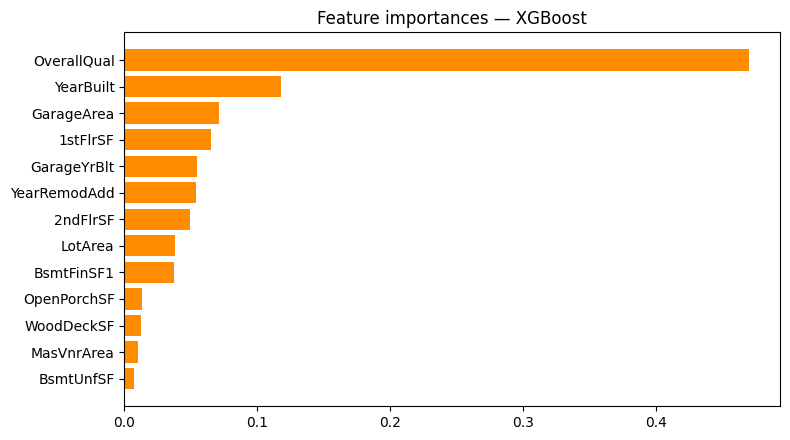

In [14]:
# Feature importances of the winning model (sanity check vs the EDA selection)
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
    plt.figure(figsize=(8, 4.5))
    plt.barh(fi.index, fi.values, color="darkorange")
    plt.title(f"Feature importances — {best_name}")
    plt.tight_layout(); plt.show()